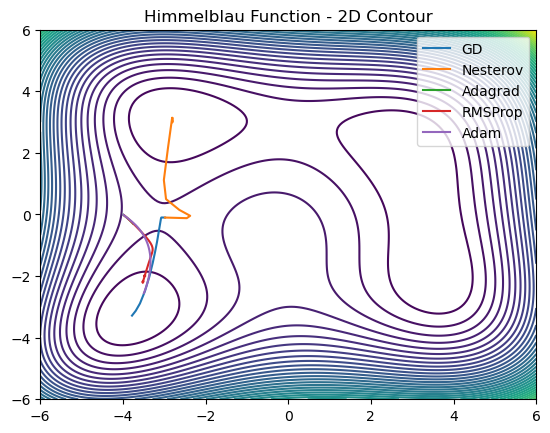

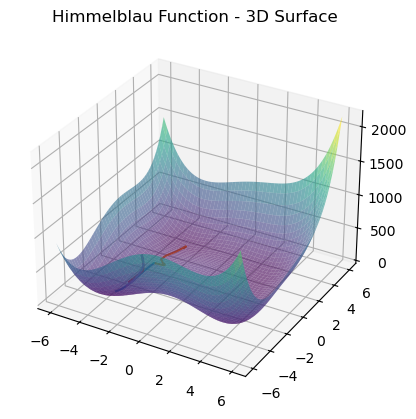

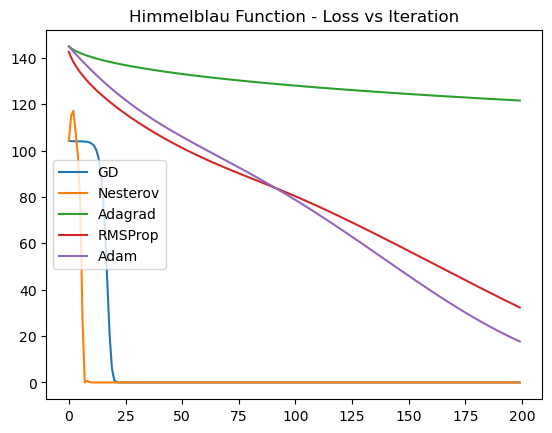

Loading MNIST dataset...


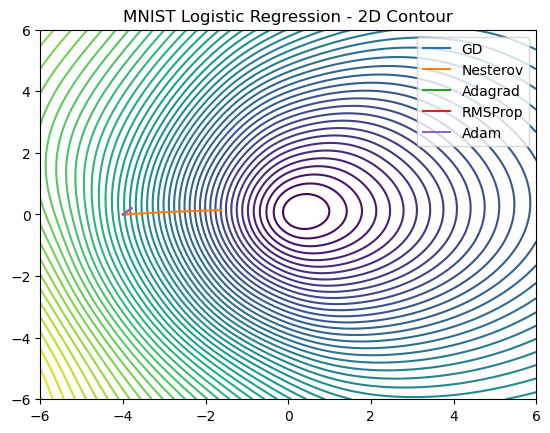

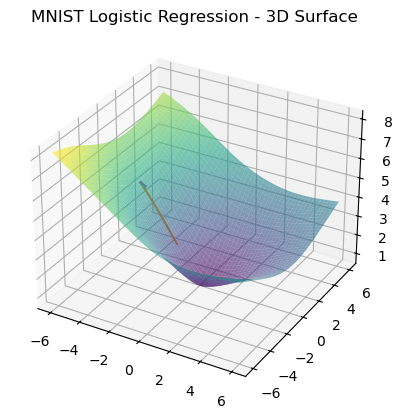

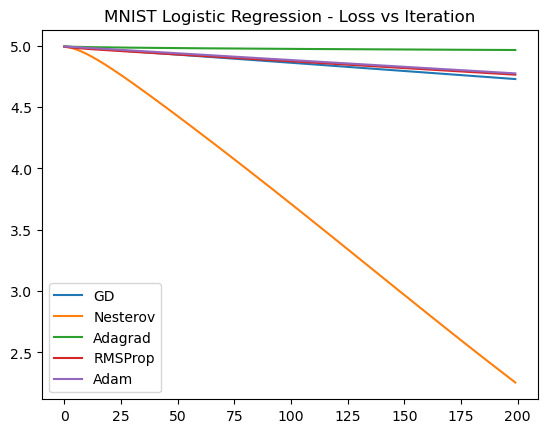

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

def himmelblau(w):
    w1, w2 = w
    return (w1**2 + w2 - 11)**2 + (w1 + w2**2 - 7)**2

def grad_himmelblau(w):
    w1, w2 = w
    df_dw1 = 4*w1*(w1**2 + w2 - 11) + 2*(w1 + w2**2 - 7)
    df_dw2 = 2*(w1**2 + w2 - 11) + 4*w2*(w1 + w2**2 - 7)
    return np.array([df_dw1, df_dw2])
def run_optimizer(grad_func, loss_func, w_init, method, lr=0.01, epochs=200):
    w = w_init.copy()
    history = []

    v = np.zeros_like(w)
    G = np.zeros_like(w)
    m_adam = np.zeros_like(w)
    v_adam = np.zeros_like(w)

    for t in range(1, epochs+1):
        grad = grad_func(w)

        if method == "GD":
            w -= lr * grad

        elif method == "Nesterov":
            momentum = 0.9
            lookahead = w - momentum * v
            grad = grad_func(lookahead)
            v = momentum * v + lr * grad
            w -= v

        elif method == "Adagrad":
            G += grad**2
            w -= (lr / (np.sqrt(G)+1e-8)) * grad

        elif method == "RMSProp":
            beta = 0.9
            G = beta*G + (1-beta)*grad**2
            w -= (lr/(np.sqrt(G)+1e-8)) * grad

        elif method == "Adam":
            b1, b2 = 0.9, 0.999
            m_adam = b1*m_adam + (1-b1)*grad
            v_adam = b2*v_adam + (1-b2)*(grad**2)
            m_hat = m_adam / (1 - b1**t)
            v_hat = v_adam / (1 - b2**t)
            w -= lr * m_hat / (np.sqrt(v_hat)+1e-8)

        history.append((w.copy(), loss_func(w)))

    return history

def visualize_2d_3d(loss_func, histories, title):
    w1 = np.linspace(-6,6,200)
    w2 = np.linspace(-6,6,200)
    W1, W2 = np.meshgrid(w1,w2)
    Z = np.array([[loss_func(np.array([x,y])) for x,y in zip(row_w1,row_w2)]
                  for row_w1,row_w2 in zip(W1,W2)])

    plt.figure()
    plt.contour(W1, W2, Z, levels=50)
    for name, hist in histories.items():
        ws = np.array([h[0] for h in hist])
        plt.plot(ws[:,0], ws[:,1], label=name)
    plt.legend()
    plt.title(f"{title} - 2D Contour")
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6)
    for name, hist in histories.items():
        ws = np.array([h[0] for h in hist])
        losses = [h[1] for h in hist]
        ax.plot(ws[:,0], ws[:,1], losses)
    ax.set_title(f"{title} - 3D Surface")
    plt.show()

    plt.figure()
    for name, hist in histories.items():
        losses = [h[1] for h in hist]
        plt.plot(losses, label=name)
    plt.legend()
    plt.title(f"{title} - Loss vs Iteration")
    plt.show()


methods = ["GD","Nesterov","Adagrad","RMSProp","Adam"]
w_init = np.array([-4.0,0.0])

histories_part1 = {}
for method in methods:
    histories_part1[method] = run_optimizer(
        grad_himmelblau,
        himmelblau,
        w_init,
        method,
        lr=0.01
    )

visualize_2d_3d(himmelblau, histories_part1, "Himmelblau Function")

print("Loading MNIST dataset...")

df = pd.read_csv(r"C:\Users\23adsb47\Downloads\archive\mnist_train.csv")

X = df.iloc[:,1:].values / 255.0
y = (df.iloc[:,0].values == 0).astype(int)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

def logistic_loss(w):
    h = sigmoid(X_reduced @ w)
    return -np.mean(y*np.log(h+1e-8)+(1-y)*np.log(1-h+1e-8))

def logistic_grad(w):
    h = sigmoid(X_reduced @ w)
    return (1/len(y))*(X_reduced.T @ (h-y))

histories_part2 = {}
for method in methods:
    histories_part2[method] = run_optimizer(
        logistic_grad,
        logistic_loss,
        w_init,
        method,
        lr=0.001  
    )

visualize_2d_3d(logistic_loss, histories_part2, "MNIST Logistic Regression")
